In [43]:
import pandas as pd
import numpy as np
import sklearn


df = pd.read_csv("C:/Users/malyk/sirius-school-proj/data/data_transformed_main.csv").set_index(["ID на сайте", "Источник"])
df["Вид объекта"] = df["Вид объекта"].replace({
    'Офис/Здание': 'Офис / Здание',
    'Торговое / Свободное назначение': 'Торговое / Свободного назначения',
    'Торговое / свободного вида': 'Торговое / Свободного назначения',
    'Торговое/Свободного назначения': 'Торговое / Свободного назначения',
})
df["Москва?"] = df["Москва?"].replace({'False': 0, 'True': 1})
df.head()

,,Цена,Дата,Тип автора,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь,Цена / м2,Москва?
ID на сайте,Источник,,,,,,,,,,,,,,,,,,
321970859,cian.ru,34500.0,2025-12-17 08:36:40,Агентство,Химки,Беломорская,"Рабочая ул., 2","НАЗВАНИЕ: Офис в Московская область, Химки Раб...",55.908036,37.432951,https://www.cian.ru/rent/commercial/321970859,https://images.cdn-cian.ru/images/2633983674-1...,9.167,4.0,4.0,Офис / Здание,23.0,1500.0,0.0
323570959,cian.ru,160500.0,2025-12-17 08:36:40,Частное лицо,Солнечногорск городской округ,Зеленоград — Крюково,21А,НАЗВАНИЕ: Торговая площадь в Московская област...,55.972650,37.099604,https://www.cian.ru/rent/commercial/323570959,https://images.cdn-cian.ru/images/torgovoe-pom...,9.167,1.0,1.0,Торговое / Свободного назначения,107.0,1500.0,0.0
319937619,cian.ru,1226740.0,2025-12-17 08:36:40,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319937619,https://images.cdn-cian.ru/images/2634163777-1...,9.167,2.0,6.0,Офис / Здание,830.0,1478.0,0.0
319936797,cian.ru,236480.0,2025-12-17 08:36:39,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319936797,https://images.cdn-cian.ru/images/2634163921-1...,9.167,2.0,6.0,Офис / Здание,160.0,1478.0,0.0
319938233,cian.ru,1537120.0,2025-12-17 08:36:38,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319938233,https://images.cdn-cian.ru/images/2569099478-1...,9.167,2.0,6.0,Офис / Здание,1040.0,1478.0,0.0


In [2]:
df.dtypes

Цена                       float64
Дата                        object
Тип автора                  object
Город                       object
Метро/Район                 object
Адрес                       object
Описание                    object
lat                        float64
lng                        float64
URL                         object
Ссылки на картинки          object
Расстояние до метро, км    float64
Этаж                       float64
Этажность здания           float64
Вид объекта                 object
Общая площадь              float64
Цена / м2                  float64
Москва?                     object
dtype: object

In [3]:
def check_column_types(df):
    """Проверяет фактические типы данных в каждом столбце"""
    results = {}
    
    for col in df.columns:
        # Получаем уникальные типы значений в столбце
        unique_types = set(type(val).__name__ for val in df[col].dropna())
        results[col] = {
            'dtype': str(df[col].dtype),
            'unique_python_types': list(unique_types),
            'type_count': len(unique_types),
            'sample_values': df[col].dropna().head(3).tolist() if not df[col].empty else []
        }
    
    # Выводим результаты
    print("Анализ типов данных в столбцах:")
    print("=" * 80)
    
    for col, info in results.items():
        print(f"\nСтолбец: {col}")
        print(f"  dtype Pandas: {info['dtype']}")
        print(f"  Python типы в данных: {info['unique_python_types']}")
        print(f"  Количество разных типов: {info['type_count']}")
        if info['sample_values']:
            print(f"  Примеры значений: {info['sample_values']}")
    
    # Столбцы с неоднородными типами
    print("\n" + "=" * 80)
    print("Столбцы с неоднородными типами данных:")
    mixed_cols = [col for col, info in results.items() if info['type_count'] > 1]
    
    if mixed_cols:
        for col in mixed_cols:
            print(f"  - {col}: {results[col]['unique_python_types']}")
    else:
        print("  Все столбцы имеют однородные типы данных")

check_column_types(df)

Анализ типов данных в столбцах:

Столбец: Цена
  dtype Pandas: float64
  Python типы в данных: ['float']
  Количество разных типов: 1
  Примеры значений: [34500.0, 160500.0, 1226740.0]

Столбец: Дата
  dtype Pandas: object
  Python типы в данных: ['str']
  Количество разных типов: 1
  Примеры значений: ['2025-12-17 08:36:40', '2025-12-17 08:36:40', '2025-12-17 08:36:40']

Столбец: Тип автора
  dtype Pandas: object
  Python типы в данных: ['str']
  Количество разных типов: 1
  Примеры значений: ['Агентство', 'Частное лицо', 'Агентство']

Столбец: Город
  dtype Pandas: object
  Python типы в данных: ['str']
  Количество разных типов: 1
  Примеры значений: ['Химки', 'Солнечногорск городской округ', 'Мытищи']

Столбец: Метро/Район
  dtype Pandas: object
  Python типы в данных: ['str']
  Количество разных типов: 1
  Примеры значений: ['Беломорская', 'Зеленоград — Крюково', 'Медведково']

Столбец: Адрес
  dtype Pandas: object
  Python типы в данных: ['str']
  Количество разных типов: 1
  При

In [4]:
# Способ 1: Восстановление правильного преобразования
print("Исправляем значения 10...")

# Сбрасываем преобразование и делаем правильно
if 'original_values' in locals():
    df["Москва?"] = original_values.copy()

# Теперь правильное преобразование
def safe_convert_to_int(value):
    """Безопасное преобразование с логикой для 1.0"""
    try:
        if pd.isna(value):
            return np.nan
        
        # Если строка
        if isinstance(value, str):
            value = value.strip()
            # Если '1.0' - убираем точку аккуратно
            if value == '1.0':
                return 1
            elif value == '0.0':
                return 0
            # Пробуем преобразовать в float, затем в int
            try:
                return int(float(value))
            except:
                # Если не число, проверяем содержание
                if '1' in value:
                    return 1
                elif '0' in value:
                    return 0
                else:
                    return np.nan
        
        # Если число
        elif isinstance(value, (int, float)):
            return int(value)
        
        return np.nan
    except:
        return np.nan

# Применяем правильное преобразование
df["Москва?"] = df["Москва?"].apply(safe_convert_to_int)

print("После исправления:")
print(f"Уникальные значения: {sorted(df['Москва?'].dropna().unique().tolist())}")
print(f"Количество 10: {(df['Москва?'] == 10).sum()}")
print(f"Распределение: {df['Москва?'].value_counts().to_dict()}")

Исправляем значения 10...
После исправления:
Уникальные значения: [0, 1]
Количество 10: 0
Распределение: {0: 29198, 1: 361}


In [5]:
from sklearn.preprocessing import (
    OneHotEncoder, OrdinalEncoder, TargetEncoder,
    StandardScaler, MinMaxScaler, RobustScaler,
)

from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, QuantileRegressor
)

from sklearn.metrics import (
    r2_score,
    root_mean_squared_error as rmse,
    mean_absolute_percentage_error as mape,
)

In [44]:
df.columns

Index(['Цена', 'Дата', 'Тип автора', 'Город', 'Метро/Район', 'Адрес',
       'Описание', 'lat', 'lng', 'URL', 'Ссылки на картинки',
       'Расстояние до метро, км', 'Этаж', 'Этажность здания', 'Вид объекта',
       'Общая площадь', 'Цена / м2', 'Москва?'],
      dtype='object')

In [7]:
df.iloc[:2]["Тип автора"]

ID на сайте  Источник
321970859    cian.ru        Агентство
323570959    cian.ru     Частное лицо
Name: Тип автора, dtype: object

In [8]:
pd.get_dummies(df['Тип автора']).astype(int)

,,Агентство,Частное лицо
ID на сайте,Источник,,
321970859,cian.ru,1,0
323570959,cian.ru,0,1
319937619,cian.ru,1,0
319936797,cian.ru,1,0
319938233,cian.ru,1,0
...,...,...,...
4750280767,avito.ru,1,0
4750437026,avito.ru,1,0
4750004434,avito.ru,1,0


In [9]:
ohe = OneHotEncoder().fit(df[['Тип автора']])
ohe.transform(df[['Тип автора']]).toarray()

array([[1., 0.],
       [0., 1.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]], shape=(29559, 2))

In [46]:
ord_enc = OrdinalEncoder().fit(df[['Вид объекта']])
ord_enc.transform(df[['Вид объекта']])

,,Вид объекта
ID на сайте,Источник,
321970859,cian.ru,0.0
323570959,cian.ru,1.0
319937619,cian.ru,0.0
319936797,cian.ru,0.0
319938233,cian.ru,0.0
...,...,...
4750280767,avito.ru,0.0
4750437026,avito.ru,0.0
4750004434,avito.ru,0.0


In [45]:
ord_enc.categories_

[array(['Офис / Здание', 'Торговое / Свободного назначения'], dtype=object)]

In [47]:
df.groupby("Вид объекта")["Цена"].mean()

Вид объекта
Офис / Здание                       496837.200929
Торговое / Свободного назначения    277255.474716
Name: Цена, dtype: float64

In [13]:
tar_enc = TargetEncoder(smooth=5).fit(df[['Вид объекта']], df["Цена"])
tar_enc.transform(df[['Вид объекта']])

array([[496754.84292232],
       [277272.21273862],
       [496754.84292232],
       ...,
       [496754.84292232],
       [496754.84292232],
       [277272.21273862]], shape=(29559, 1))

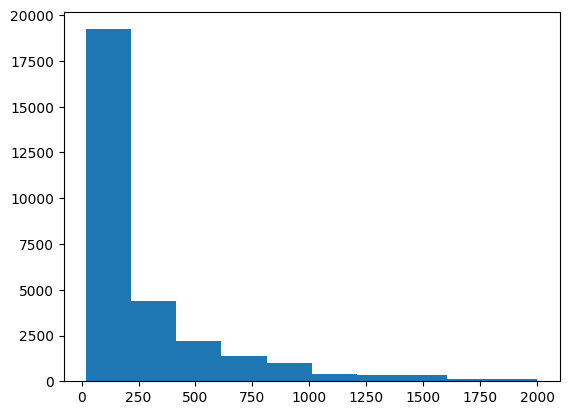

In [14]:
import matplotlib.pyplot as plt

plt.hist(df["Общая площадь"])
plt.show()

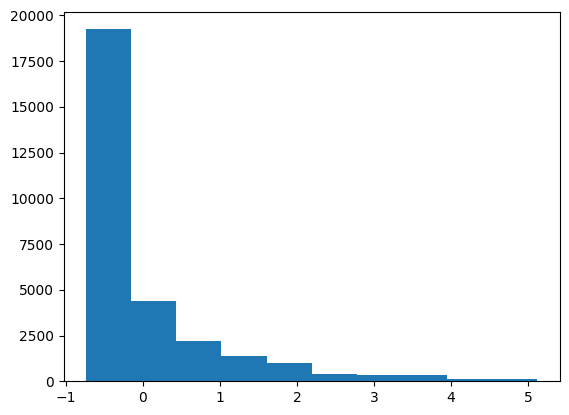

In [15]:
plt.hist(StandardScaler().fit_transform(df[["Общая площадь"]]))
plt.show()

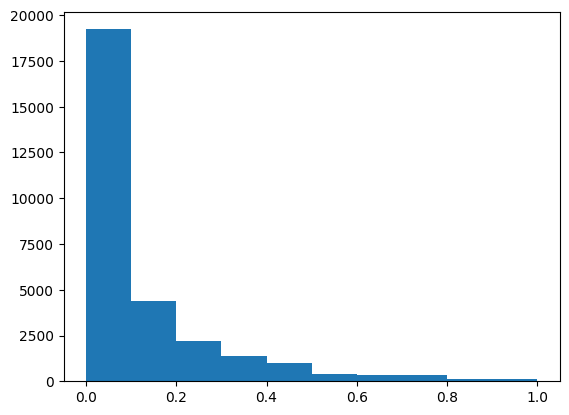

In [16]:
plt.hist(MinMaxScaler().fit_transform(df[["Общая площадь"]]))
plt.show()

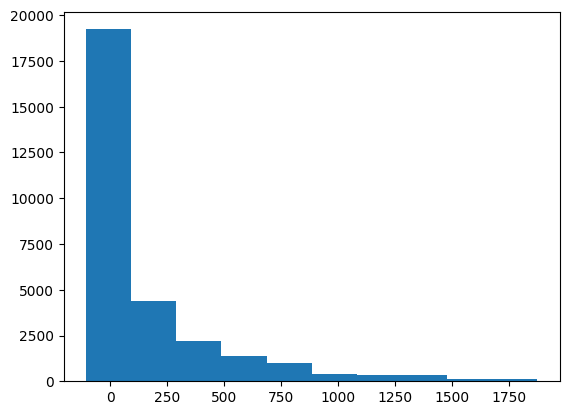

In [17]:
plt.hist(RobustScaler(quantile_range=(0.2, 0.8)).fit_transform(df[["Общая площадь"]]))
plt.show()

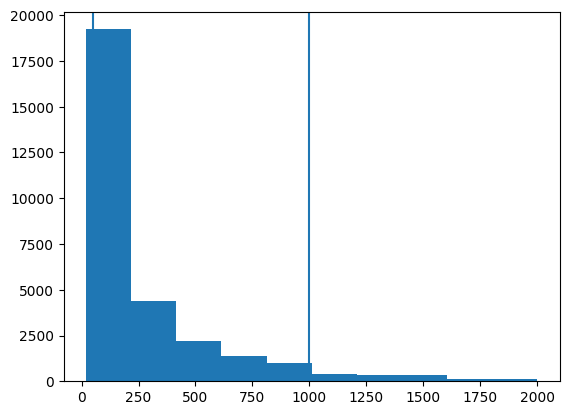

In [18]:
plt.hist(df["Общая площадь"])
plt.axvline(df["Общая площадь"].quantile(0.2))
plt.axvline(df["Общая площадь"].quantile(0.95))
plt.show()

In [19]:
df.columns

Index(['Цена', 'Дата', 'Тип автора', 'Город', 'Метро/Район', 'Адрес',
       'Описание', 'lat', 'lng', 'URL', 'Ссылки на картинки',
       'Расстояние до метро, км', 'Этаж', 'Этажность здания', 'Вид объекта',
       'Общая площадь', 'Цена / м2', 'Москва?'],
      dtype='object')

In [20]:
from sklearn.compose import ColumnTransformer

from sklearn import set_config
set_config(transform_output="pandas")

ct = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), ["Общая площадь", "Расстояние до метро, км"]),
        ("onehot", OneHotEncoder(sparse_output=False), ["Вид объекта"]),
        ("ordinal", OrdinalEncoder(), ["Тип автора"]),
    ],
    remainder="passthrough",
    n_jobs=-1,
).set_output(transform="pandas")

ct.fit(df)

,transformers,"[('scale', ...), ('onehot', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [21]:
ct.transform(df)

,,scale__Общая площадь,"scale__Расстояние до метро, км",onehot__Вид объекта_Офис / Здание,onehot__Вид объекта_Торговое / Свободного назначения,ordinal__Тип автора,remainder__Цена,remainder__Дата,remainder__Город,remainder__Метро/Район,remainder__Адрес,remainder__Описание,remainder__lat,remainder__lng,remainder__URL,remainder__Ссылки на картинки,remainder__Этаж,remainder__Этажность здания,remainder__Цена / м2,remainder__Москва?
ID на сайте,Источник,,,,,,,,,,,,,,,,,,,
321970859,cian.ru,-0.727409,-0.071871,1.0,0.0,0.0,34500.0,2025-12-17 08:36:40,Химки,Беломорская,"Рабочая ул., 2","НАЗВАНИЕ: Офис в Московская область, Химки Раб...",55.908036,37.432951,https://www.cian.ru/rent/commercial/321970859,https://images.cdn-cian.ru/images/2633983674-1...,4.0,4.0,1500.000000,0
323570959,cian.ru,-0.479083,-0.071871,0.0,1.0,1.0,160500.0,2025-12-17 08:36:40,Солнечногорск городской округ,Зеленоград — Крюково,21А,НАЗВАНИЕ: Торговая площадь в Московская област...,55.972650,37.099604,https://www.cian.ru/rent/commercial/323570959,https://images.cdn-cian.ru/images/torgovoe-pom...,1.0,1.0,1500.000000,0
319937619,cian.ru,1.658292,-0.071871,1.0,0.0,0.0,1226740.0,2025-12-17 08:36:40,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319937619,https://images.cdn-cian.ru/images/2634163777-1...,2.0,6.0,1478.000000,0
319936797,cian.ru,-0.322401,-0.071871,1.0,0.0,0.0,236480.0,2025-12-17 08:36:39,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319936797,https://images.cdn-cian.ru/images/2634163921-1...,2.0,6.0,1478.000000,0
319938233,cian.ru,2.279106,-0.071871,1.0,0.0,0.0,1537120.0,2025-12-17 08:36:38,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319938233,https://images.cdn-cian.ru/images/2569099478-1...,2.0,6.0,1478.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4750280767,avito.ru,0.730322,-0.871338,1.0,0.0,0.0,736325.0,2025-02-28 14:19:30,Химки,Химки,"Московская обл., Химки, ул. Панфилова, 19с1",НАЗВАНИЕ: Офисное помещение 516.12 кв.м от соб...,55.881490,37.432933,https://www.avito.ru/himki/kommercheskaya_nedv...,https://30.img.avito.st/image/1/1.AlU-sba5rrwI...,1.0,NaN,1426.709940,0
4750437026,avito.ru,-0.256772,-0.838334,1.0,0.0,0.0,270000.0,2025-02-28 14:19:23,Котельники,Котельники,"Московская обл., Котельники, Дзержинское ш., 2",НАЗВАНИЕ: Офисное помещение 182.24 кв.м от соб...,55.654477,37.856443,https://www.avito.ru/kotelniki/kommercheskaya_...,https://10.img.avito.st/image/1/1.xz3K9La5a9T8...,5.0,NaN,1481.888035,0
4750004434,avito.ru,0.744808,-0.871338,1.0,0.0,0.0,743442.0,2025-02-28 14:19:06,Химки,Химки,"Московская обл., Химки, ул. Панфилова, 19с1",НАЗВАНИЕ: Офисное помещение 521 кв.м от собств...,55.881490,37.432933,https://www.avito.ru/himki/kommercheskaya_nedv...,https://70.img.avito.st/image/1/1.y5athra5Z3-b...,1.0,NaN,1426.952015,0


In [22]:
df.shape

(29559, 18)

In [23]:
from sklearn.model_selection import train_test_split

y = df["Цена"].copy()
X = df[["Общая площадь", "Расстояние до метро, км", "Вид объекта", "Тип автора", "Москва?"]].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=X["Вид объекта"])

In [24]:
X_train["Вид объекта"].value_counts() / X_train.shape[0] * 100

Вид объекта
Торговое / Свободного назначения    68.929586
Офис / Здание                       31.070414
Name: count, dtype: float64

In [25]:
X_test["Вид объекта"].value_counts() / X_test.shape[0] * 100

Вид объекта
Торговое / Свободного назначения    68.930988
Офис / Здание                       31.069012
Name: count, dtype: float64

In [26]:
X_test.isna().sum()

Общая площадь                 0
Расстояние до метро, км    2209
Вид объекта                   0
Тип автора                    0
Москва?                       0
dtype: int64

In [27]:
from sklearn.impute import SimpleImputer

si = SimpleImputer(strategy="constant", fill_value=100, add_indicator=True).fit(X_train[["Расстояние до метро, км"]])
X_train_fillna = si.transform(X_train[["Расстояние до метро, км"]])
X_test_fillna = si.transform(X_test[["Расстояние до метро, км"]])

In [28]:
X_train = pd.concat([X_train.drop("Расстояние до метро, км", axis=1), X_train_fillna], axis=1)
X_test = pd.concat([X_test.drop("Расстояние до метро, км", axis=1), X_test_fillna], axis=1)

X_train.head()

,,Общая площадь,Вид объекта,Тип автора,Москва?,"Расстояние до метро, км","missingindicator_Расстояние до метро, км"
ID на сайте,Источник,,,,,,
3965285094499585728,realty.yandex.ru,300.0,Офис / Здание,Агентство,0,31.167,0.0
321217196,cian.ru,70.0,Торговое / Свободного назначения,Агентство,0,100.000,1.0
6125479316747978337,realty.yandex.ru,700.0,Офис / Здание,Агентство,0,10.083,0.0
7320679609,avito.ru,460.0,Торговое / Свободного назначения,Агентство,0,100.000,1.0
319630305,cian.ru,158.0,Торговое / Свободного назначения,Агентство,0,25.667,0.0


In [49]:
ct = ColumnTransformer(
    transformers=[
        
        ("scale", StandardScaler(), ["Общая площадь", "Расстояние до метро, км"]),
        ("onehot", OneHotEncoder(sparse_output=False), ["Вид объекта"]),
        ("ordinal", OrdinalEncoder(), ["Тип автора"]),
    ],
    remainder="passthrough",
    n_jobs=-1,
).set_output(transform="pandas")

ct.fit(X_train)

,transformers,"[('scale', ...), ('onehot', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [50]:
X_train_pre = ct.transform(X_train)
X_test_pre = ct.transform(X_test)

In [51]:
model = LinearRegression().fit(X_train_pre, y_train)

In [52]:
y_pred = model.predict(X_train_pre)
y_test_pred = model.predict(X_test_pre)

In [53]:
r2_score(y_train, y_pred), rmse(y_train, y_pred), mape(y_train, y_pred)

(0.7194283848848181,
 np.float64(222991.70825286306),
 np.float64(70.45963086362609))

In [54]:
r2_score(y_test, y_test_pred), rmse(y_test, y_test_pred), mape(y_test, y_test_pred)

(0.7470017156323971,
 np.float64(214688.96241894268),
 np.float64(69.45260758976664))

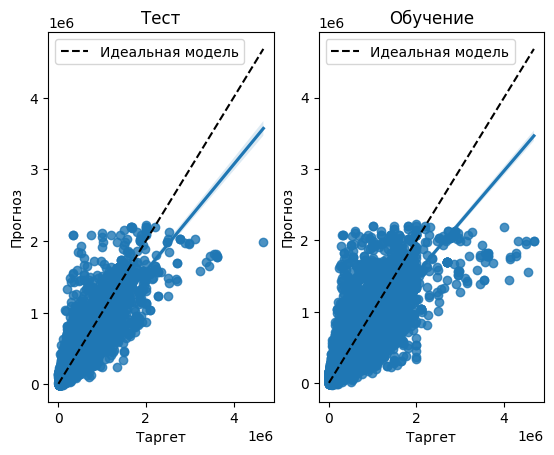

In [55]:
import seaborn as sns

fig, axis = plt.subplots(ncols=2)
sns.regplot(x=y_test, y=y_test_pred, ax=axis[0])
sns.regplot(x=y_train, y=y_pred, ax=axis[1])

for i, y_true in enumerate([y_test, y_train]):
    lims = [np.min(y_true), np.max(y_true)]
    axis[i].plot(lims, lims, linestyle="--", color="black", label="Идеальная модель")

axis[0].set_title("Тест")
axis[1].set_title("Обучение")
for i in [0, 1]:
    axis[i].set_xlabel("Таргет")
    axis[i].set_ylabel("Прогноз")
    axis[i].legend()
plt.show()

In [56]:
import sys

sys.path.append("..")

import viz

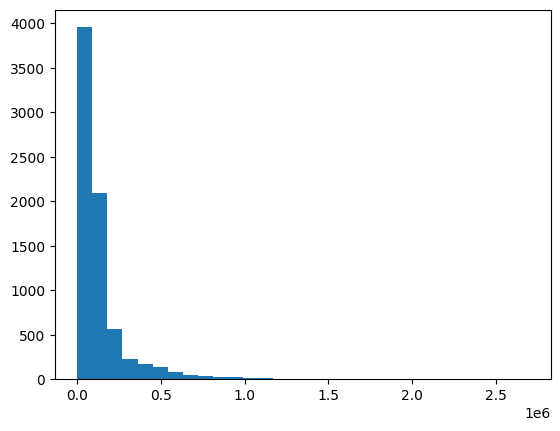

In [57]:
plt.hist(np.abs(y_test - y_test_pred), bins=30)
plt.show()

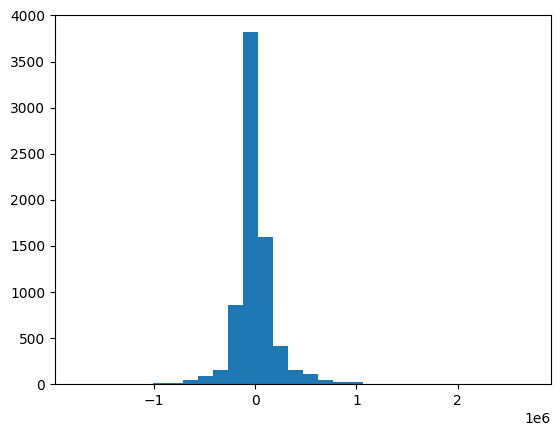

In [38]:
plt.hist(y_test - y_test_pred, bins=30)
plt.show()

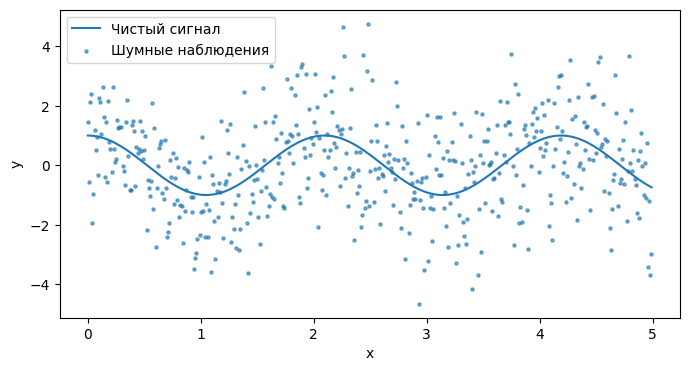

In [39]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)  # фиксируем сид для воспроизводимости

Xs = np.arange(0, 500) / 100
signal = np.cos(3 * Xs)

noise = rng.normal(loc=0.0, scale=1.5, size=len(Xs))  # N(0, 2^2)
ys = signal + noise

plt.figure(figsize=(8, 4))
plt.plot(Xs, signal, label="Чистый сигнал")
plt.scatter(Xs, ys, s=5, alpha=0.6, label="Шумные наблюдения")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

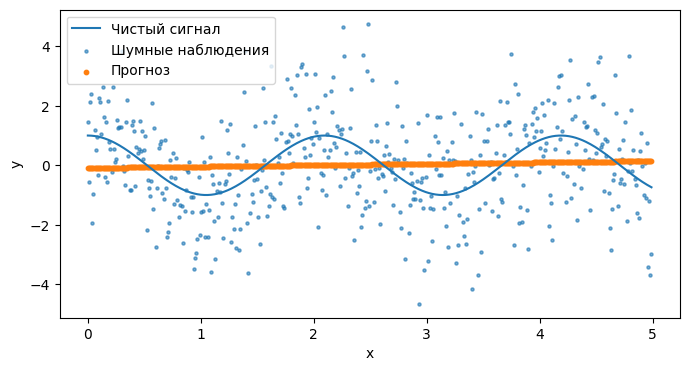

In [40]:
lrs = LinearRegression().fit(Xs.reshape(-1, 1), ys)
ys_pred = lrs.predict(Xs.reshape(-1, 1))

plt.figure(figsize=(8, 4))
plt.plot(Xs, signal, label="Чистый сигнал")
plt.scatter(Xs, ys, s=5, alpha=0.6, label="Шумные наблюдения")
plt.scatter(Xs, ys_pred, s=10, label="Прогноз")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

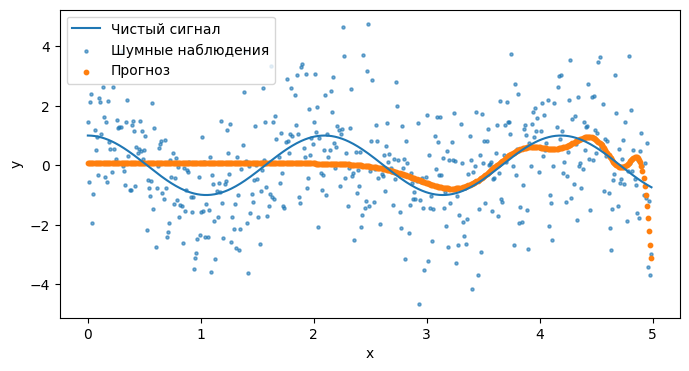

In [41]:
from sklearn.preprocessing import PolynomialFeatures

Xsp = PolynomialFeatures(degree=30).fit_transform(Xs.reshape(-1, 1)).drop("1", axis=1)

lrs = LinearRegression().fit(Xsp, ys)
ys_pred = lrs.predict(Xsp)

plt.figure(figsize=(8, 4))
plt.plot(Xs, signal, label="Чистый сигнал")
plt.scatter(Xs, ys, s=5, alpha=0.6, label="Шумные наблюдения")
plt.scatter(Xs, ys_pred, s=10, label="Прогноз")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [67]:
import optuna
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import numpy as np

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

optuna.logging.set_verbosity(optuna.logging.WARNING)

FIXED_KWARGS = {
    'tol': 1e-5,
    'random_state': 42,
}

CV = KFold(n_splits=5, random_state=10, shuffle=True)

def objective(trial, X, y):
    params = {
        'alpha': trial.suggest_float('alpha', low=1e-6, high=100),
        'max_iter': trial.suggest_int('max_iter', low=500, high=5000),
        'solver': trial.suggest_categorical('solver', ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']),
    }
    
    params.update(FIXED_KWARGS)
    model = Ridge(**params).fit(X, y)
    scores = cross_validate(
        model,
        X, y,
        scoring="r2",
        cv=CV,
        n_jobs=-1,
    )
    return scores['test_score'].mean()


def study_results(study):
    trial = study.best_trial
    print('Best CV={} score: {:.6}'.format(CV, trial.value))
    print('Best params:')
    for key, value in trial.params.items():
        print("    {}: {}".format(key, value))


def plot_study(study):
    fig_list = [
        optuna.visualization.plot_optimization_history(study),
        optuna.visualization.plot_param_importances(study),
    ]
    for fig in fig_list:
        fig.update_layout(width=900)
        fig.show()

study = optuna.create_study(
    sampler=optuna.samplers.TPESampler(),
    pruner=optuna.pruners.HyperbandPruner(),
    direction="maximize",
)

study.optimize(lambda trial: objective(trial, X_train_pre, y_train),
               n_trials=100, timeout=3*60, gc_after_trial=True, show_progress_bar=True)

study_results(study)

plot_study(study)

params = study.best_trial.params
params.update(FIXED_KWARGS)

model = Ridge(**params).fit(X_train_pre, y_train)
y_test_pred = model.predict(X_test_pre)

print("Результаты на тестовой выборке:")
print(f"R2 Score: {r2_score(y_test, y_test_pred):.6f}")
print(f"RMSE: {rmse(y_test, y_test_pred):.6f}")
print(f"MAPE: {mape(y_test, y_test_pred):.6f}%")

  0%|          | 0/100 [00:00<?, ?it/s]

Best CV=KFold(n_splits=5, random_state=10, shuffle=True) score: 0.719113
Best params:
    alpha: 3.2523256369187816
    max_iter: 2244
    solver: sparse_cg


Результаты на тестовой выборке:
R2 Score: 0.747018
RMSE: 214682.018026
MAPE: 69.430206%


In [61]:
from sklearn.linear_model import Lasso, ElasticNet, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd
import time

# Функции метрик (если еще не определены)
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mape(y_true, y_pred):
    mask = y_true != 0  # Избегаем деления на ноль
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Функция очистки названий столбцов
def clean_column_names(df):
    """Очищает названия столбцов от специальных символов для LightGBM"""
    df = df.copy()
    df.columns = [
        str(col).replace('[', '_').replace(']', '_').replace('<', '_').replace('>', '_')
        .replace(' ', '_').replace(',', '_').replace(':', '_')
        .replace(';', '_').replace('|', '_').replace('/', '_')
        .replace('\\', '_').replace('?', '_').replace('*', '_')
        .replace('+', '_').replace('=', '_').replace('&', '_')
        .replace('%', '_').replace('$', '_').replace('#', '_')
        .replace('@', '_').replace('!', '_').replace('~', '_')
        .replace('`', '_').replace('"', '_').replace("'", '_')
        .replace('(', '_').replace(')', '_').replace('{', '_')
        .replace('}', '_').replace('^', '_') 
        for col in df.columns
    ]
    # Убираем множественные подчеркивания
    df.columns = [col.replace('__', '_').replace('__', '_').strip('_') for col in df.columns]
    return df

# Очищаем названия столбцов (ВАЖНО для LightGBM)
print("Очистка названий столбцов...")
X_train_pre_clean = clean_column_names(X_train_pre)
X_test_pre_clean = clean_column_names(X_test_pre)

# Проверяем названия столбцов
print("\nПример очищенных названий столбцов:")
for i, col in enumerate(X_train_pre_clean.columns[:5]):
    print(f"  {i+1}. {col}")

# Определяем модели для сравнения
models_to_try = {
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42, max_iter=5000),
    'ElasticNet': ElasticNet(random_state=42, max_iter=5000),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
}

# Сравниваем модели
results = {}
training_times = {}

print("\n" + "="*70)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*70)

for name, model in models_to_try.items():
    print(f"\nОбучение модели: {name}")
    
    # Замер времени обучения
    start_time = time.time()
    
    try:
        # Обучение модели
        if name == 'LightGBM':
            # Для LightGBM используем очищенные данные
            model.fit(X_train_pre_clean, y_train)
            y_pred = model.predict(X_test_pre_clean)
        else:
            # Для остальных моделей можно использовать оригинальные или очищенные
            model.fit(X_train_pre_clean, y_train)
            y_pred = model.predict(X_test_pre_clean)
        
        # Расчет метрик
        r2 = r2_score(y_test, y_pred)
        rmse_val = rmse(y_test, y_pred)
        mape_val = mape(y_test, y_pred)
        
        # Сохранение результатов
        results[name] = {
            'R2': r2,
            'RMSE': rmse_val,
            'MAPE': mape_val
        }
        
        training_time = time.time() - start_time
        training_times[name] = training_time
        
        print(f"  ✓ Обучение завершено за {training_time:.2f} сек")
        print(f"    R2: {r2:.4f}, RMSE: {rmse_val:,.0f}, MAPE: {mape_val:.2f}%")
        
    except Exception as e:
        print(f"  ✗ Ошибка при обучении {name}: {str(e)}")
        results[name] = {
            'R2': np.nan,
            'RMSE': np.nan,
            'MAPE': np.nan
        }
        training_times[name] = np.nan

# Создаем DataFrame с результатами
results_df = pd.DataFrame(results).T
results_df['Время обучения (сек)'] = pd.Series(training_times)

# Добавляем ранжирование по R2
results_df['Ранг по R2'] = results_df['R2'].rank(ascending=False, method='min')
results_df['Ранг по RMSE'] = results_df['RMSE'].rank(ascending=True, method='min')
results_df['Ранг по MAPE'] = results_df['MAPE'].rank(ascending=True, method='min')

# Общий ранг (средний)
results_df['Общий ранг'] = results_df[['Ранг по R2', 'Ранг по RMSE', 'Ранг по MAPE']].mean(axis=1)
results_df = results_df.sort_values('Общий ранг')

print("\n" + "="*70)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ (отсортировано по лучшим)")
print("="*70)
print(results_df.round(4))

Очистка названий столбцов...

Пример очищенных названий столбцов:
  1. scale_Общая_площадь
  2. scale_Расстояние_до_метро_км
  3. onehot_Вид_объекта_Офис_Здание
  4. onehot_Вид_объекта_Торговое_Свободного_назначения
  5. ordinal_Тип_автора

СРАВНЕНИЕ МОДЕЛЕЙ

Обучение модели: Ridge
  ✓ Обучение завершено за 0.01 сек
    R2: 0.7470, RMSE: 214,687, MAPE: 69.45%

Обучение модели: Lasso
  ✓ Обучение завершено за 1.35 сек
    R2: 0.7470, RMSE: 214,689, MAPE: 69.45%

Обучение модели: ElasticNet
  ✓ Обучение завершено за 0.04 сек
    R2: 0.6641, RMSE: 247,377, MAPE: 113.99%

Обучение модели: RandomForest
  ✓ Обучение завершено за 0.41 сек
    R2: 0.8160, RMSE: 183,102, MAPE: 46.05%

Обучение модели: GradientBoosting
  ✓ Обучение завершено за 0.93 сек
    R2: 0.8124, RMSE: 184,885, MAPE: 50.15%

Обучение модели: XGBoost
  ✓ Обучение завершено за 0.12 сек
    R2: 0.8182, RMSE: 182,002, MAPE: 47.02%

Обучение модели: LightGBM
  ✓ Обучение завершено за 0.08 сек
    R2: 0.8226, RMSE: 179,782, MAPE

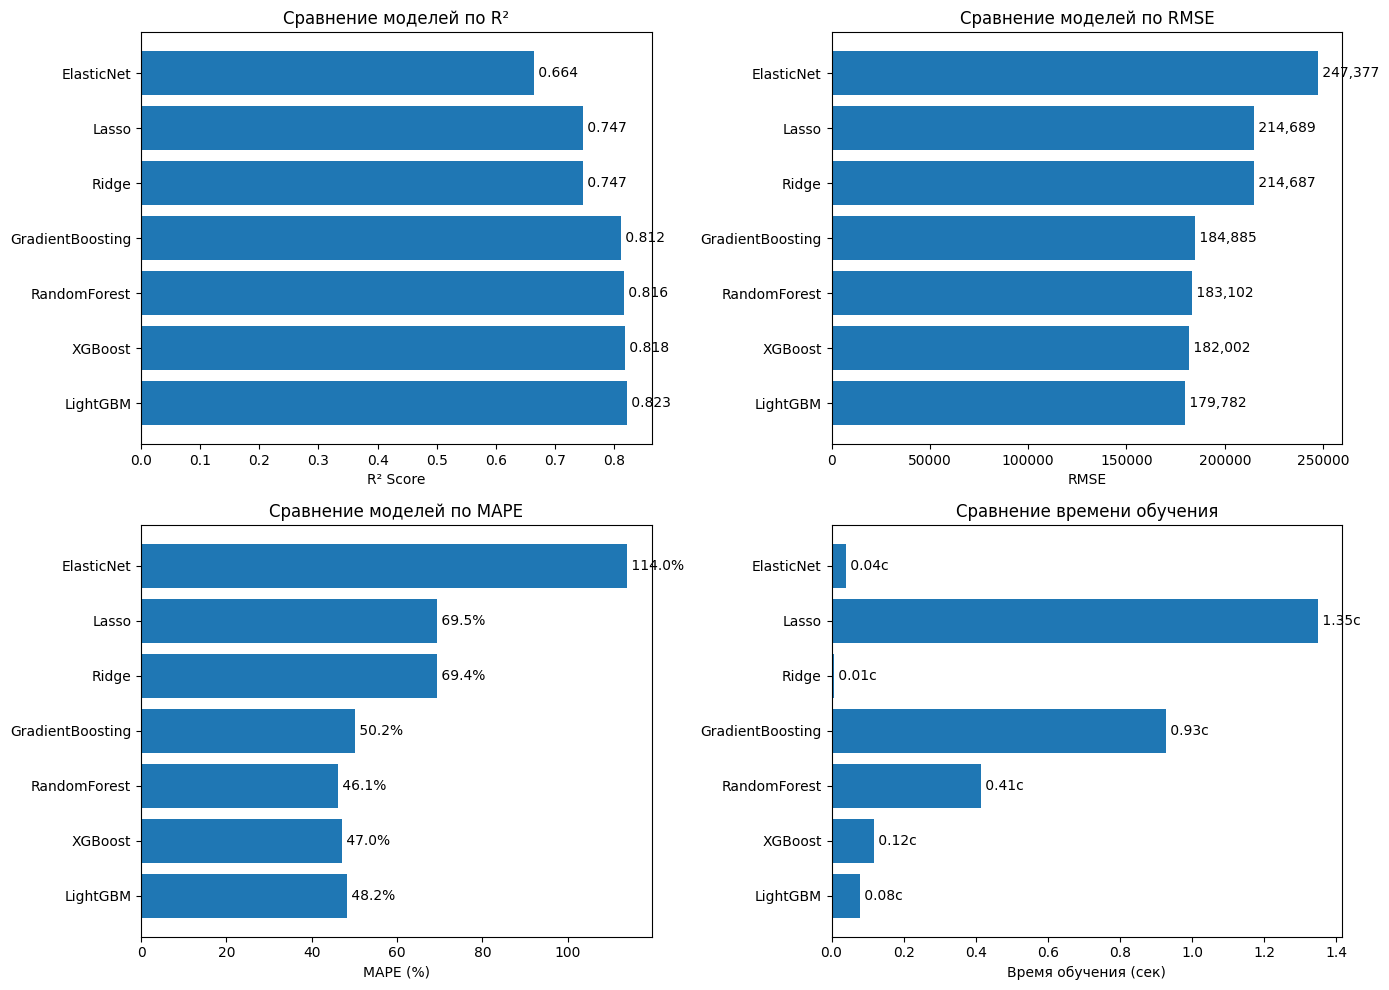

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].barh(results_df.index, results_df['R2'])
axes[0, 0].set_xlabel('R² Score')
axes[0, 0].set_title('Сравнение моделей по R²')
axes[0, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
for i, v in enumerate(results_df['R2']):
    axes[0, 0].text(v, i, f' {v:.3f}', va='center')

axes[0, 1].barh(results_df.index, results_df['RMSE'])
axes[0, 1].set_xlabel('RMSE')
axes[0, 1].set_title('Сравнение моделей по RMSE')
for i, v in enumerate(results_df['RMSE']):
    axes[0, 1].text(v, i, f' {v:,.0f}', va='center')

axes[1, 0].barh(results_df.index, results_df['MAPE'])
axes[1, 0].set_xlabel('MAPE (%)')
axes[1, 0].set_title('Сравнение моделей по MAPE')
for i, v in enumerate(results_df['MAPE']):
    axes[1, 0].text(v, i, f' {v:.1f}%', va='center')

axes[1, 1].barh(results_df.index, results_df['Время обучения (сек)'])
axes[1, 1].set_xlabel('Время обучения (сек)')
axes[1, 1].set_title('Сравнение времени обучения')
for i, v in enumerate(results_df['Время обучения (сек)']):
    axes[1, 1].text(v, i, f' {v:.2f}с', va='center')

plt.tight_layout()
plt.show()

In [69]:
import optuna
import lightgbm as lgb
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

# Метрики
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mape(y_true, y_pred):
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Тихий режим
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Фиксированные параметры
FIXED_KWARGS = {
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1,
}

# CV стратегия
CV = KFold(n_splits=5, random_state=10, shuffle=True)

# Очистка названий для LightGBM
def clean_column_names(df):
    df = df.copy()
    df.columns = [str(col).replace('[', '_').replace(']', '_').replace(' ', '_').replace(',', '_') 
                  for col in df.columns]
    df.columns = [col.replace('__', '_').strip('_') for col in df.columns]
    return df

# Целевая функция
def objective(trial, X, y):
    params = {
        # Основные параметры
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        
        # Сложность деревьев
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        
        # Регуляризация
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        
        # Борьба с переобучением
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    
    params.update(FIXED_KWARGS)
    model = lgb.LGBMRegressor(**params)
    
    scores = cross_validate(
        model, X, y,
        scoring="r2",
        cv=CV,
        n_jobs=1,  # LightGBM лучше с n_jobs=1
    )
    
    return scores['test_score'].mean()

# Вывод результатов
def study_results(study):
    trial = study.best_trial
    print(f'Best CV score: {trial.value:.6f}')
    print('Best params:')
    for key, value in trial.params.items():
        print(f"    {key}: {value}")

# Визуализация
def plot_study(study):
    fig_list = [
        optuna.visualization.plot_optimization_history(study),
        optuna.visualization.plot_param_importances(study),
    ]
    for fig in fig_list:
        fig.update_layout(width=900)
        fig.show()

# ============ ОСНОВНОЙ КОД ============

# Очищаем данные
X_train_clean = clean_column_names(X_train_pre)
X_test_clean = clean_column_names(X_test_pre)

# Создаем study
study = optuna.create_study(
    sampler=optuna.samplers.TPESampler(),
    pruner=optuna.pruners.HyperbandPruner(),
    direction="maximize",
)

# Оптимизация
study.optimize(lambda trial: objective(trial, X_train_clean, y_train),
               n_trials=50, timeout=180, gc_after_trial=True, show_progress_bar=True)

# Результаты
study_results(study)
plot_study(study)

# Финальная модель
params = study.best_trial.params
params.update(FIXED_KWARGS)

model = lgb.LGBMRegressor(**params).fit(X_train_clean, y_train)
y_test_pred = model.predict(X_test_clean)

print("\nРезультаты на тестовой выборке:")
print(f"R2 Score: {r2_score(y_test, y_test_pred):.6f}")
print(f"RMSE: {rmse(y_test, y_test_pred):.6f}")
print(f"MAPE: {mape(y_test, y_test_pred):.6f}%")

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X_train_clean.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-5 важных признаков:")
print(feature_importance.head(5).to_string(index=False))

  0%|          | 0/50 [00:00<?, ?it/s]

Best CV score: 0.798811
Best params:
    n_estimators: 340
    learning_rate: 0.15642019894036585
    num_leaves: 26
    max_depth: 8
    reg_alpha: 0.000681177495407942
    reg_lambda: 2.976067198582704
    subsample: 0.9781401703408708
    colsample_bytree: 0.9376636851377673



Результаты на тестовой выборке:
R2 Score: 0.818807
RMSE: 181685.838639
MAPE: 47.182239%

Топ-5 важных признаков:
                         feature  importance
             scale_Общая_площадь        4187
    scale_Расстояние_до_метро_км        3567
onehot_Вид_объекта_Офис_/_Здание         520
              ordinal_Тип_автора         123
               remainder_Москва?          85


In [71]:
import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    return mean_absolute_percentage_error(y_true, y_pred) * 100

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Очистка названий для LightGBM
def clean_column_names(df):
    df = df.copy()
    df.columns = [str(col).replace('[', '_').replace(']', '_').replace(' ', '_').replace(',', '_') 
                  for col in df.columns]
    df.columns = [col.replace('__', '_').strip('_') for col in df.columns]
    return df

def objective(trial, X, y):
    params = {
        # Основные параметры
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        
        # Сложность деревьев
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        
        # Регуляризация
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        
        # Борьба с переобучением
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        
        # Фиксированные
        'boosting_type': 'gbdt',  # Фиксируем для скорости
        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1,
    }
    
    try:
        model = lgb.LGBMRegressor(**params)
        
        # Используем 3 фолда вместо 5 для скорости
        cv = KFold(n_splits=3, shuffle=True, random_state=42)
        
        # Только R2 для скорости (основная метрика из таблицы)
        scores = cross_val_score(
            model, X, y,
            scoring='r2',
            cv=cv,
            n_jobs=1,  # LightGBM лучше с n_jobs=1 при кросс-валидации
            error_score='raise'
        )
        
        return scores.mean()
        
    except Exception as e:
        # Возвращаем плохое значение при ошибке
        return -1.0

# Вывод результатов
def study_results(study):
    if not study.best_trial:
        print("Нет успешных trials!")
        return
    
    trial = study.best_trial
    print(f"\n{'='*60}")
    print(f"ЛУЧШИЙ РЕЗУЛЬТАТ")
    print(f"{'='*60}")
    print(f"R2 (CV среднее): {trial.value:.6f}")
    
    if trial.user_attrs:
        print(f"Дополнительные метрики:")
        for key, value in trial.user_attrs.items():
            if key not in ['params', 'datetime_start', 'datetime_complete']:
                print(f"  {key}: {value}")
    
    print(f"\nЛучшие гиперпараметры:")
    for key, value in trial.params.items():
        print(f"  {key}: {value}")

# ============ ОСНОВНОЙ КОД ============

# Очищаем данные
X_train_clean = clean_column_names(X_train_pre)
X_test_clean = clean_column_names(X_test_pre)

print("Начинаем оптимизацию гиперпараметров...")
print(f"Размер обучающей выборки: {X_train_clean.shape}")
print(f"Размер тестовой выборки: {X_test_clean.shape}")
print(f"Целевая переменная: Цена")
print(f"Количество признаков: {X_train_clean.shape[1]}")
print("="*60)

# Создаем study с БОЛЕЕ ПРОСТЫМИ настройками
study = optuna.create_study(
    study_name="lightgbm_fast_optimization",
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)

# Оптимизация с обработкой ошибок
try:
    study.optimize(
        lambda trial: objective(trial, X_train_clean, y_train),
        n_trials=50,  # Уменьшили для скорости
        timeout=300,  # 5 минут максимум
        show_progress_bar=True,
        catch=(Exception,),
    )
except Exception as e:
    print(f"Ошибка в оптимизации: {e}")
    print("Продолжаем с лучшими найденными параметрами...")

# Результаты
study_results(study)

# Если есть успешные trials, продолжаем
if study.best_trial and study.best_trial.value > -0.5:
    print("\n" + "="*60)
    print("ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ...")
    print("="*60)
    
    # Берем лучшие параметры
    best_params = study.best_trial.params.copy()
    
    # Добавляем фиксированные параметры
    fixed_params = {
        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1,
        'boosting_type': 'gbdt',
    }
    best_params.update(fixed_params)
    
    # Увеличиваем n_estimators для финальной модели
    best_params['n_estimators'] = 500  # Фиксируем для стабильности
    
    print("Параметры модели:")
    for key, value in best_params.items():
        if key not in ['verbose', 'n_jobs']:
            print(f"    '{key}': {value},")
    
    # Обучаем финальную модель
    model = lgb.LGBMRegressor(**best_params)
    model.fit(X_train_clean, y_train)
    
    # Предсказания
    y_test_pred = model.predict(X_test_clean)
    
    # Метрики
    r2 = r2_score(y_test, y_test_pred)
    rmse_val = rmse(y_test, y_test_pred)
    mape_val = mape(y_test, y_test_pred)
    
    print("\n" + "="*60)
    print("РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ:")
    print("="*60)
    print(f"R2 Score: {r2:.6f}")
    print(f"RMSE: {rmse_val:.6f}")
    print(f"MAPE: {mape_val:.6f}%")
    
    print("\n" + "="*60)
    print("СРАВНЕНИЕ С ТАБЛИЦЕЙ:")
    print("="*60)
    print(f"{'Модель':<20} {'R2':<10} {'RMSE':<15} {'MAPE':<10}")
    print("-"*55)
    print(f"{'LightGBM (исходный)':<20} {0.8226:<10.4f} {179782.2747:<15.2f} {48.2099:<10.2f}")
    print(f"{'LightGBM (оптимизированный)':<20} {r2:<10.4f} {rmse_val:<15.2f} {mape_val:<10.2f}")
    
    # Проверяем улучшение
    improvement = r2 - 0.8226
    if improvement > 0:
        print(f"\n✅ УЛУЧШЕНИЕ R2: +{improvement:.4f}")
    else:
        print(f"\n⚠️  R2 УХУДШИЛСЯ на: {abs(improvement):.4f}")
    
    # Важность признаков
    if hasattr(model, 'feature_importances_'):
        feature_importance = pd.DataFrame({
            'feature': X_train_clean.columns,
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print("\n" + "="*60)
        print("ТОП-5 ВАЖНЫХ ПРИЗНАКОВ:")
        print("="*60)
        print(feature_importance.head(5).to_string(index=False))
    
else:
    print("\n" + "="*60)
    print("ВНИМАНИЕ: Не удалось найти хорошие параметры.")
    print("Используем параметры по умолчанию...")
    print("="*60)
    
    # Параметры по умолчанию
    default_params = {
        'n_estimators': 500,
        'learning_rate': 0.05,
        'num_leaves': 31,
        'max_depth': -1,
        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1,
    }
    
    model = lgb.LGBMRegressor(**default_params)
    model.fit(X_train_clean, y_train)
    
    y_test_pred = model.predict(X_test_clean)
    
    r2 = r2_score(y_test, y_test_pred)
    rmse_val = rmse(y_test, y_test_pred)
    mape_val = mape(y_test, y_test_pred)
    
    print(f"R2 Score: {r2:.6f}")
    print(f"RMSE: {rmse_val:.6f}")
    print(f"MAPE: {mape_val:.6f}%")

Начинаем оптимизацию гиперпараметров...
Размер обучающей выборки: (22169, 7)
Размер тестовой выборки: (7390, 7)
Целевая переменная: Цена
Количество признаков: 7


  0%|          | 0/50 [00:00<?, ?it/s]


ЛУЧШИЙ РЕЗУЛЬТАТ
R2 (CV среднее): 0.789967

Лучшие гиперпараметры:
  n_estimators: 741
  learning_rate: 0.06345328931528044
  num_leaves: 84
  max_depth: 12
  min_child_samples: 49
  reg_alpha: 2.412430431608682e-06
  reg_lambda: 0.00041500393882170944
  subsample: 0.6519144795225364
  colsample_bytree: 0.6660865748856766

ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ...
Параметры модели:
    'n_estimators': 500,
    'learning_rate': 0.06345328931528044,
    'num_leaves': 84,
    'max_depth': 12,
    'min_child_samples': 49,
    'reg_alpha': 2.412430431608682e-06,
    'reg_lambda': 0.00041500393882170944,
    'subsample': 0.6519144795225364,
    'colsample_bytree': 0.6660865748856766,
    'random_state': 42,
    'boosting_type': gbdt,

РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ:
R2 Score: 0.822715
RMSE: 179716.173052
MAPE: 49.507907%

СРАВНЕНИЕ С ТАБЛИЦЕЙ:
Модель               R2         RMSE            MAPE      
-------------------------------------------------------
LightGBM (исходный)  0.8226     179782.27      